In [1]:
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "font.serif": ["Computer Modern"],
})

def mm(cc, cx, xx, fx=0.1):
    return (1-fx)**2 *cc+fx*(1-fx)*cx+fx**2 * xx
import sys
sys.path.append('/home/fverdian/class/soundspeed-scripts/numerical-integrals')
from num_kernels import NumKernels

In [2]:
kmax, dcdc13, dcdc13_EdS, dcTc13, dcTc13_EdS, dcdx13, dcdx13_EdS, dcTx13, dcTx13_EdS, dxdx13, dxdx13_EdS, PL_cc, TL_x, dcdx_IR  =np.loadtxt(f'/home/fverdian/class/soundspeed-scripts/numerical-integrals/cutofftests/P13_varykmax-ma26p0-fx0p1-N1000-p2.txt', unpack=True)[:,:70]


In [5]:
fx=0.1
t_ini = -7
fullt=np.linspace(t_ini,30, 300)
teval=0
kref =8.4e12 * pow(1.e-26/0.67,1/2) * 0.666**0.25
supprshift=8
p=2
nk = NumKernels(fx=fx, kref=kref, fullt=fullt, rtol=0.0001, p=p, supprshift=supprshift)

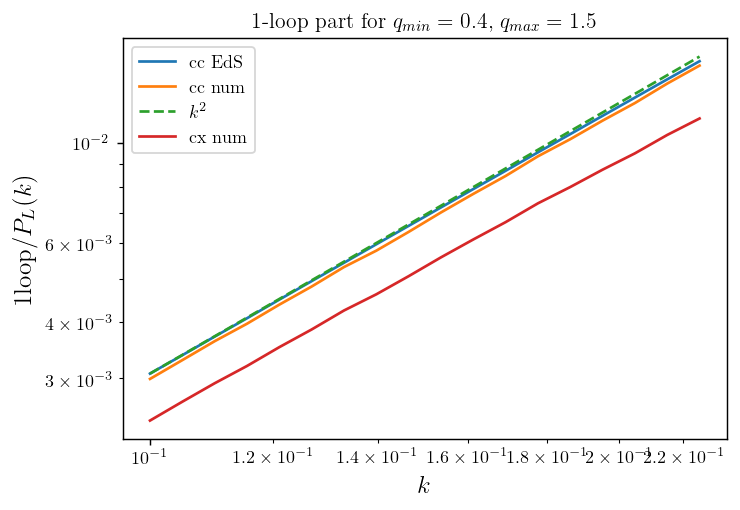

In [67]:
plt.figure(figsize=(6,4), dpi=130)

plt.loglog(kmax, -(dcdc13_EdS)/PL_cc, label='cc EdS')
plt.loglog(kmax, -(dcdc13)/PL_cc, label='cc num')

plt.loglog(kmax, (-dcdc13_EdS[0]/PL_cc[0])*(kmax/kmax[0])**2, label=r'$k^2$', linestyle='--')

plt.loglog(kmax, -(dcdx13)/PL_cc, label='cx num')


plt.title(r'1-loop part for $q_{min}=0.4$, $q_{max}=1.5$')
plt.legend()
# plt.ylabel(r'$F/F_\mathrm{EdS}-1$', fontsize=14)
plt.xlabel(r'$k$', fontsize=14)
plt.ylabel(r'1loop/$P_L(k)$', fontsize=14)

plt.show()

In [14]:
qlist=np.logspace(np.log10(0.01),np.log10(10.5),30)
Flist=[];Flist_EdS=[]
mup=1.
kp=0.15
for qp in qlist:
    print(f'q={qp:.1e}', end='\r', flush=True)
    kMq = np.sqrt(kp**2 + qp**2 - 2*kp*qp*mup)
    cT12 = (kp*mup-qp)/kMq
    F3c, G3c , F3x, G3x=nk.solve_F3([kp,qp,mup])
    Flist.append([F3c,F3x,nk.F3_0(kp,qp,mup),G3c,G3x,nk.G3_0(kp,qp,mup)])
Flist=np.array(Flist).T

-----
### Just looking at the kernels

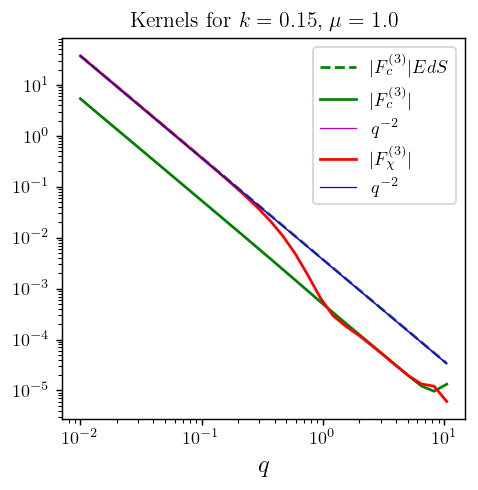

In [13]:
plt.figure(figsize=(4,3.8), dpi=130)

plt.plot(qlist, np.abs(Flist[2]), 'g--', label=r'$|F_c^{(3)}| EdS$')
plt.plot(qlist, 1/7*np.abs(Flist[0]), 'g', label=r'$|F_c^{(3)}|$')
plt.plot(qlist, -Flist[2,0]*(pow(qlist,-2)/pow(qlist[0],-2)), 'm', label=r'$q^{-2}$', linewidth=0.7)

plt.plot(qlist, np.abs(Flist[1]), 'r', label=r'$|F_\chi^{(3)}|$')
plt.plot(qlist, -Flist[1,0]*nk.g_an(-(2+p)*np.log(kp/kref))*(pow(qlist,-2)/pow(qlist[0],-2)), 'b', label=r'$q^{-2}$', linewidth=0.7)

plt.legend()
plt.title(r'Kernels for $k='+'%.2f'%kp+r'$, $\mu='+'%.1f'%mup+r'$')
# plt.ylabel(r'$F/F_\mathrm{EdS}-1$', fontsize=14)
plt.xlabel(r'$q$', fontsize=14)
plt.xscale('log')
plt.yscale('log')
# plt.savefig('/home/fverdian/class/soundspeed-scripts/figure/F3_limitB_ofq.pdf', bbox_inches='tight')
plt.show()

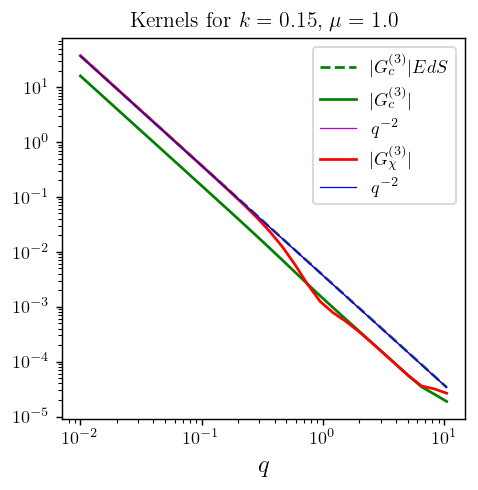

In [16]:
plt.figure(figsize=(4,3.8), dpi=130)

plt.plot(qlist, np.abs(Flist[5]), 'g--', label=r'$|G_c^{(3)}| EdS$')
plt.plot(qlist, 3/7*np.abs(Flist[3]), 'g', label=r'$|G_c^{(3)}|$')
plt.plot(qlist, -Flist[5,0]*(pow(qlist,-2)/pow(qlist[0],-2)), 'm', label=r'$q^{-2}$', linewidth=0.7)

plt.plot(qlist, np.abs(Flist[4]), 'r', label=r'$|G_\chi^{(3)}|$')
plt.plot(qlist, -Flist[4,0]*nk.g_an(-(2+p)*np.log(kp/kref))*(pow(qlist,-2)/pow(qlist[0],-2)), 'b', label=r'$q^{-2}$', linewidth=0.7)

plt.legend()
plt.title(r'Kernels for $k='+'%.2f'%kp+r'$, $\mu='+'%.1f'%mup+r'$')
# plt.ylabel(r'$F/F_\mathrm{EdS}-1$', fontsize=14)
plt.xlabel(r'$q$', fontsize=14)
plt.xscale('log')
plt.yscale('log')
# plt.savefig('/home/fverdian/class/soundspeed-scripts/figure/F3_limitB_ofq.pdf', bbox_inches='tight')
plt.show()